In [1]:
# Install/update the YOLO training dependencies for this notebook.
# Run once if ultralytics is not available in the current kernel.
%pip install ultralytics pyyaml matplotlib pillow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import ultralytics

print("torch:", torch.__version__, "cuda:", torch.version.cuda)
ultralytics.checks()


Ultralytics 8.4.54  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Setup complete  (16 CPUs, 7.7 GB RAM, 90.1/309.4 GB disk)


In [3]:
import torch

assert torch.cuda.is_available(), "CUDA not available. Install a CUDA-enabled PyTorch build before training."
DEVICE = 0
print("gpu:", torch.cuda.get_device_name(0))
print("device:", DEVICE)


gpu: NVIDIA GeForce RTX 3050 6GB Laptop GPU
device: 0


In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATASETS_ROOT = PROJECT_ROOT / "datasets"
MERGED_DET_DIR = DATASETS_ROOT / "merged_detection_yolo26"
DATA_YAML = MERGED_DET_DIR / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs"
PREP_SCRIPT = PROJECT_ROOT / "prepare_yolo26_dataset.py"

# Keep this small by default for RTX 3050 6GB. Change to yolo26s.pt/l.pt only if VRAM allows.
BASE_MODEL = "yolo26n.pt"
RUN_NAME = "poultry_carcass_yolo26_detect"
IMG_SIZE = 640
BATCH = 8
EPOCHS = 100
PATIENCE = 15
WORKERS = 2
SEED = 42

print("project_root:", PROJECT_ROOT)
print("datasets_root:", DATASETS_ROOT)
print("merged_dataset:", MERGED_DET_DIR)
print("data_yaml:", DATA_YAML)
print("runs_dir:", RUNS_DIR)


project_root: d:\poultry_carcass_defect_detection
datasets_root: d:\poultry_carcass_defect_detection\datasets
merged_dataset: d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26
data_yaml: d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\data.yaml
runs_dir: d:\poultry_carcass_defect_detection\runs


In [5]:
# Rebuild the merged detection dataset from the downloaded Roboflow exports.
# This keeps the notebook reproducible if a dataset folder is refreshed later.
assert PREP_SCRIPT.exists(), f"Missing preprocessing script: {PREP_SCRIPT}"
%run prepare_yolo26_dataset.py
assert DATA_YAML.exists(), f"Missing data.yaml after preparation: {DATA_YAML}"


Prepared: D:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26
Images copied: 4688
Label files written: 4688
Objects written: 6845
Objects skipped: 1918
Objects per class:
  bile: 425
  bruise: 2792
  dislocation: 453
  feather: 158
  fracture: 145
  hematoma: 452
  scratch: 24
  skin-rash: 208
  abnormal-carcass: 24
  technical-failure: 3
  fecal-contamination: 2161


In [6]:
import yaml
from collections import Counter

with DATA_YAML.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]
print("nc:", data_cfg["nc"])
print("classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
for split in ("train", "valid", "test"):
    image_dir = MERGED_DET_DIR / split / "images"
    label_dir = MERGED_DET_DIR / split / "labels"
    images = [p for p in image_dir.iterdir() if p.suffix.lower() in image_exts]
    labels = list(label_dir.glob("*.txt"))
    print(split, "images:", len(images), "labels:", len(labels))


nc: 11
classes:
  0: bile
  1: bruise
  2: dislocation
  3: feather
  4: fracture
  5: hematoma
  6: scratch
  7: skin-rash
  8: abnormal-carcass
  9: technical-failure
  10: fecal-contamination
train images: 3929 labels: 3929
valid images: 468 labels: 468
test images: 291 labels: 291


In [7]:
# Annotation sanity check: every image has a label file and every label line is YOLO detection format.
missing_labels = []
orphan_labels = []
bad_lines = []
objects_per_class = Counter()

for split in ("train", "valid", "test"):
    image_dir = MERGED_DET_DIR / split / "images"
    label_dir = MERGED_DET_DIR / split / "labels"
    image_stems = {p.stem for p in image_dir.iterdir() if p.suffix.lower() in image_exts}
    label_stems = {p.stem for p in label_dir.glob("*.txt")}
    missing_labels.extend((split, s) for s in sorted(image_stems - label_stems))
    orphan_labels.extend((split, s) for s in sorted(label_stems - image_stems))

    for label_path in label_dir.glob("*.txt"):
        for line_no, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) != 5:
                bad_lines.append((label_path, line_no, "token_count", line))
                continue
            try:
                cls = int(parts[0])
                x, y, w, h = [float(v) for v in parts[1:]]
            except ValueError:
                bad_lines.append((label_path, line_no, "parse", line))
                continue
            if cls < 0 or cls >= len(class_names) or not all(0.0 <= v <= 1.0 for v in (x, y, w, h)) or w <= 0 or h <= 0:
                bad_lines.append((label_path, line_no, "range", line))
                continue
            objects_per_class[class_names[cls]] += 1

print("missing_labels:", len(missing_labels))
print("orphan_labels:", len(orphan_labels))
print("bad_lines:", len(bad_lines))
print("objects_per_class:")
for name in class_names:
    print(f"  {name}: {objects_per_class[name]}")

assert not missing_labels, missing_labels[:5]
assert not orphan_labels, orphan_labels[:5]
assert not bad_lines, bad_lines[:5]


missing_labels: 0
orphan_labels: 0
bad_lines: 0
objects_per_class:
  bile: 425
  bruise: 2792
  dislocation: 453
  feather: 158
  fracture: 145
  hematoma: 452
  scratch: 24
  skin-rash: 208
  abnormal-carcass: 24
  technical-failure: 3
  fecal-contamination: 2161


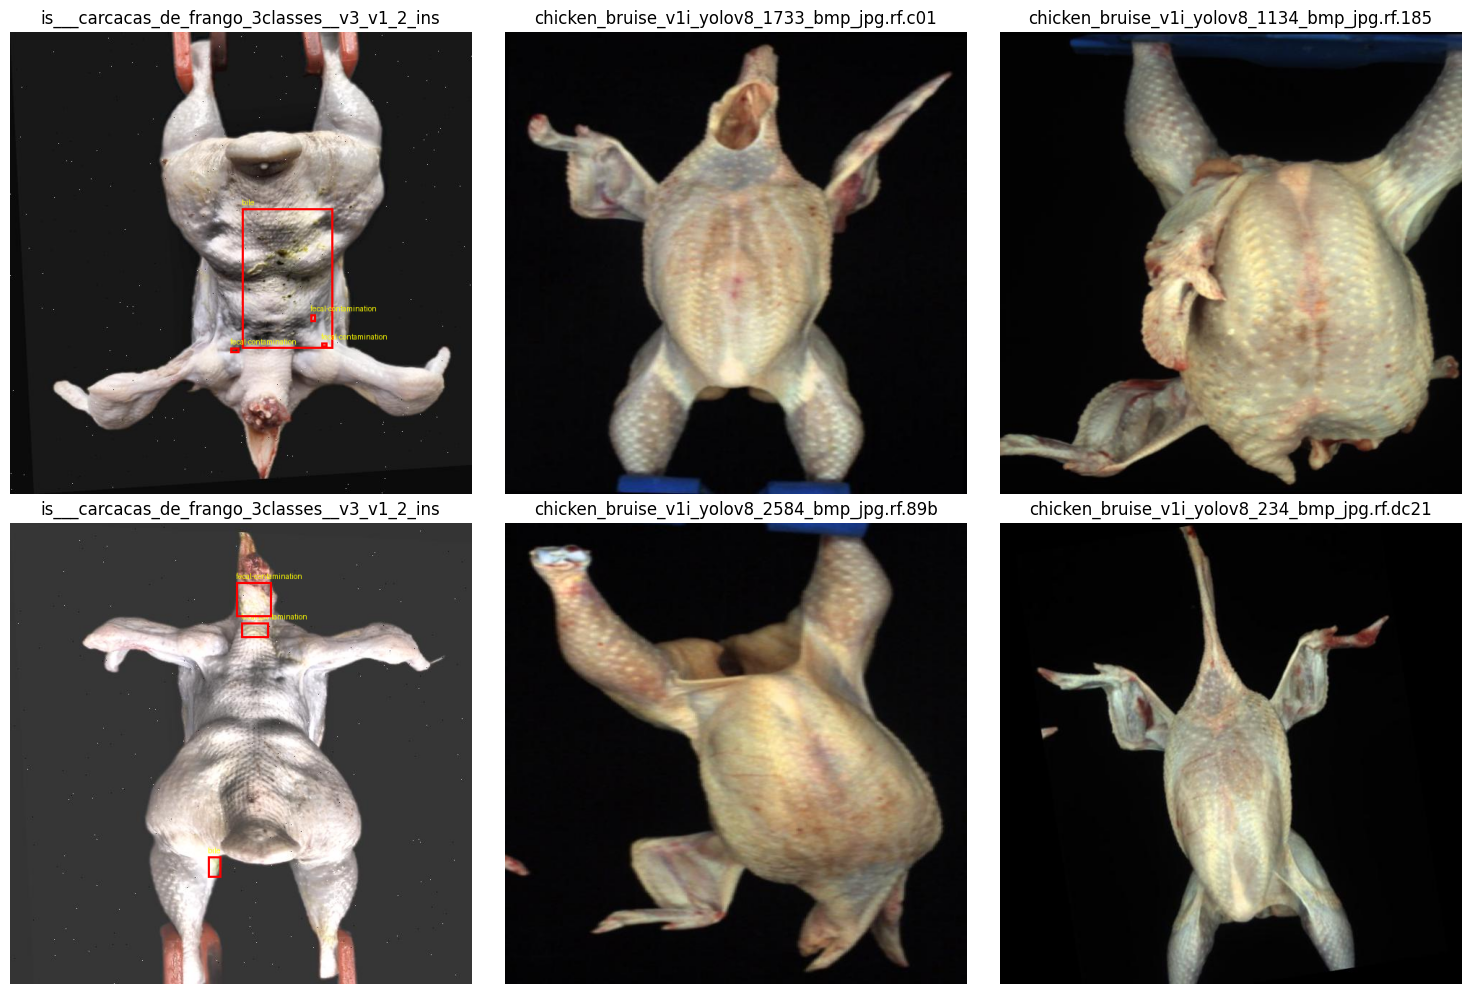

In [8]:
# Visual check: draw a few training labels before training.
import random
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

random.seed(SEED)
train_images = sorted([p for p in (MERGED_DET_DIR / "train" / "images").iterdir() if p.suffix.lower() in image_exts])
samples = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, img_path in zip(axes, samples):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    w_img, h_img = img.size
    label_path = MERGED_DET_DIR / "train" / "labels" / f"{img_path.stem}.txt"
    for line in label_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        cls, x, y, bw, bh = line.split()
        cls = int(cls)
        x, y, bw, bh = map(float, (x, y, bw, bh))
        x1 = int((x - bw / 2) * w_img)
        y1 = int((y - bh / 2) * h_img)
        x2 = int((x + bw / 2) * w_img)
        y2 = int((y + bh / 2) * h_img)
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 14)), class_names[cls], fill="yellow")
    ax.imshow(img)
    ax.set_title(img_path.name[:45])
    ax.axis("off")

plt.tight_layout()
plt.show()


# Train

This project is a YOLO detection task for poultry carcass defects. The training dataset is `datasets/merged_detection_yolo26/data.yaml`.

The default model is `yolo26n.pt` because the available GPU has 6 GB VRAM. Increase to `yolo26s.pt` or `yolo26l.pt` only after confirming memory is enough.


In [9]:
from ultralytics import YOLO

model = YOLO(BASE_MODEL)
train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    name=RUN_NAME,
    project=str(RUNS_DIR),
    workers=WORKERS,
    verbose=True,
    patience=PATIENCE,
    optimizer="AdamW",
    lr0=5e-4,
    lrf=1e-2,
    cos_lr=True,
    amp=True,
    plots=True,
    seed=SEED,
    exist_ok=True,
)
print("train_save_dir:", train_results.save_dir)


New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.54  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

In [10]:
# Resume training only if the previous training run was interrupted.
from ultralytics import YOLO

last_path = RUNS_DIR / RUN_NAME / "weights" / "last.pt"
print("last_path:", last_path)
if last_path.exists():
    model = YOLO(str(last_path))
    resume_results = model.train(resume=True)
    print("resume_save_dir:", resume_results.save_dir)
else:
    print("No last.pt found. Run the training cell first.")


last_path: d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\last.pt
New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
WARNING model 'd:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.54  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100

KeyboardInterrupt: 

# Val

Validate the best model on the validation split and inspect the metrics/plots saved in the run folder.


In [5]:
from pathlib import Path
import torch
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd()
RUNS_DIR = PROJECT_ROOT / "runs"
RUN_NAME = "poultry_carcass_yolo26_detect"
DATA_YAML = PROJECT_ROOT / "datasets" / "merged_detection_yolo26" / "data.yaml"

IMG_SIZE = 640
BATCH = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"

best_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

print("best_path:", best_path)
assert best_path.exists(), f"Missing best weights: {best_path}"

model = YOLO(str(best_path))
metrics = model.val(
    data=str(DATA_YAML),
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_val",
    exist_ok=True,
    plots=True,
)

print("val_metrics:", metrics)

best_path: d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.pt
Ultralytics 8.4.54  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 237.993.4 MB/s, size: 28.7 KB)
val: Scanning D:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\valid\labels.cache... 468 images, 178 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 468/468  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 11.4it/s 5.2s0.1s
                   all        468        992      0.434      0.477      0.347      0.205
                  bile         24         36      0.283      0.444      0.274      0.116
                bruise        188        491      0.324      0.607      0.362      0.157
           dislocation         71         87      0.28

# Predict

Run predictions on the held-out test images and save visual outputs for manual inspection.


In [7]:
from pathlib import Path
import torch
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd()
MERGED_DET_DIR = PROJECT_ROOT / "datasets" / "merged_detection_yolo26"
RUNS_DIR = PROJECT_ROOT / "runs"
RUN_NAME = "poultry_carcass_yolo26_detect"

IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else "cpu"

best_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
TEST_IMAGES = MERGED_DET_DIR / "test" / "images"

print("best_path:", best_path)
print("test_images:", TEST_IMAGES)

assert best_path.exists(), f"Missing best weights: {best_path}"
assert TEST_IMAGES.exists(), f"Missing test images folder: {TEST_IMAGES}"

model = YOLO(str(best_path))
pred_results = model.predict(
    source=str(TEST_IMAGES),
    imgsz=IMG_SIZE,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_test_predictions",
    exist_ok=True,
    save=True,
)

print("prediction_batches:", len(pred_results))

best_path: d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.pt
test_images: d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\test\images

image 1/291 d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\test\images\chicken_bruise_v1i_yolov8_1004_bmp_jpg.rf.c137f404f4fe62bd42c3324bf4aa8448.jpg: 640x640 3 bruises, 69.0ms
image 2/291 d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\test\images\chicken_bruise_v1i_yolov8_1008_bmp_jpg.rf.e4f8b3e5d52c143ba74333afb9429a85.jpg: 640x640 2 bruises, 67.7ms
image 3/291 d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\test\images\chicken_bruise_v1i_yolov8_1009_bmp_jpg.rf.aa776bba77a590bbd0f8880cd3975d04.jpg: 640x640 (no detections), 67.0ms
image 4/291 d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\test\images\chicken_bruise_v1i_yolov8_1014_bmp_jpg.rf.ce87a10911279f62d77748ea8ca828f8.jpg: 640x640 1 bruise, 1 skin-rash, 

In [10]:
# Predict one sample and print detected class names/confidences.
from pathlib import Path
import torch
import yaml
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd()
MERGED_DET_DIR = PROJECT_ROOT / "datasets" / "merged_detection_yolo26"
DATA_YAML = MERGED_DET_DIR / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs"
RUN_NAME = "poultry_carcass_yolo26_detect"

IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else "cpu"

best_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
TEST_IMAGES = MERGED_DET_DIR / "test" / "images"

assert best_path.exists(), f"Missing best weights: {best_path}"
assert TEST_IMAGES.exists(), f"Missing test images folder: {TEST_IMAGES}"

with DATA_YAML.open("r", encoding="utf-8") as f:
    class_names = yaml.safe_load(f)["names"]

model = YOLO(str(best_path))
sample = next(TEST_IMAGES.glob("*"))

pred = model.predict(
    source=str(sample),
    imgsz=IMG_SIZE,
    conf=0.25,
    device=DEVICE,
    save=True,
    verbose=False,
)

print("sample:", sample)
for box in pred[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(class_names[cls_id], round(conf, 4), box.xyxy[0].tolist())

Results saved to D:\poultry_carcass_defect_detection\runs\detect\predict-3
sample: d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\test\images\chicken_bruise_v1i_yolov8_1004_bmp_jpg.rf.c137f404f4fe62bd42c3324bf4aa8448.jpg
bruise 0.5359 [218.17759704589844, 197.30056762695312, 237.764404296875, 232.24859619140625]
bruise 0.4849 [164.22845458984375, 322.4267272949219, 181.27879333496094, 365.6631774902344]
bruise 0.3945 [491.6214294433594, 467.1688537597656, 520.9662475585938, 499.7688903808594]


# Export

Export the trained detector after training is complete. ONNX is useful for deployment and later app integration.


In [11]:
from ultralytics import YOLO

try:
    best_path = Path(train_results.save_dir) / "weights" / "best.pt"
except Exception:
    best_path = RUNS_DIR / RUN_NAME / "weights" / "best.pt"

model = YOLO(str(best_path))
onnx_path = model.export(format="onnx", imgsz=IMG_SIZE, dynamic=True, simplify=True)
print("onnx:", onnx_path)


Ultralytics 8.4.54  Python-3.12.10 torch-2.5.1+cu121 CPU (13th Gen Intel Core i5-13450HX)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'd:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.21.0 opset 19...


c:\Users\dell_\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\onnx\symbolic_opset9.py:5385: UserWarning: Exporting aten::index operator of advanced indexing in opset 19 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  4.6s, saved as 'd:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx' (10.5 MB)

Export complete (5.2s)
Results saved to D:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx
Predict:         yolo predict task=detect model=d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx imgsz=640 data=d:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\data.yaml  
Visualize:       https://netron.app
onnx: d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx


In [12]:
# Validate exported ONNX model if export was completed.
from ultralytics import YOLO

try:
    onnx_model_path = Path(onnx_path)
except Exception:
    onnx_model_path = RUNS_DIR / RUN_NAME / "weights" / "best.onnx"

print("onnx_model_path:", onnx_model_path)
if onnx_model_path.exists():
    onnx_model = YOLO(str(onnx_model_path), task="detect")
    onnx_metrics = onnx_model.val(data=str(DATA_YAML), imgsz=IMG_SIZE, batch=BATCH, device=DEVICE, task="detect")
    print("onnx_val_metrics:", onnx_metrics)
else:
    print("ONNX model not found yet. Run the export cell first.")


onnx_model_path: d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx
Ultralytics 8.4.54  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Loading d:\poultry_carcass_defect_detection\runs\poultry_carcass_yolo26_detect\weights\best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider
val: Fast image access  (ping: 0.10.0 ms, read: 90.117.9 MB/s, size: 25.9 KB)
val: Scanning D:\poultry_carcass_defect_detection\datasets\merged_detection_yolo26\valid\labels.cache... 468 images, 178 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 468/468  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 9.4it/s 6.2s<0.2s
                   all        468        992      0.434      0.477      0.347      0.205
                  bile         24         36      0.283      0.444      0.275      0.116
                bruise        188      

# Notes

- `patience=15` is the early-stopping setting. Training stops if validation performance does not improve for 15 epochs.
- Keep `batch=8` for RTX 3050 6 GB. If CUDA runs out of memory, reduce to `batch=4`.
- Final PyTorch weights: `runs/poultry_carcass_yolo26_detect/weights/best.pt`.
- Dataset YAML: `datasets/merged_detection_yolo26/data.yaml`.
